# Credit Card Fraud Detection Using XGBoost

## Problem Statement
Credit card fraud poses a major threat to digital financial transactions.  
Fraudulent transactions are extremely rare compared to legitimate transactions, making classification highly challenging due to class imbalance.

**Objective of this project:**
- Build a fraud detection model using XGBoost
- Handle imbalanced data
- Evaluate performance using suitable metrics
- Identify important features contributing to prediction

In [31]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [33]:
# Dataset Reading
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


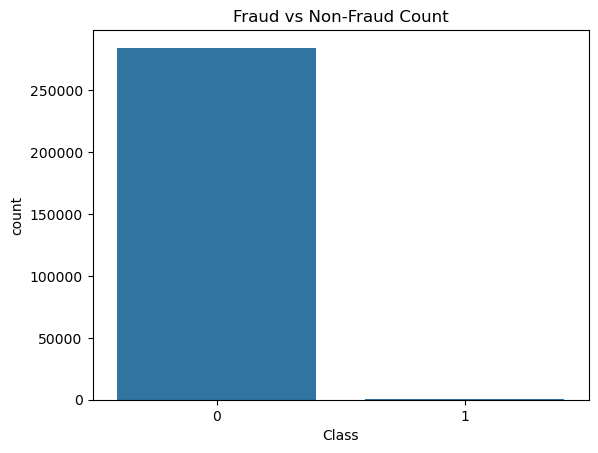

In [34]:
# 1) Fraud vs Non-Fraud Count
sns.countplot(x=df["Class"])
plt.title("Fraud vs Non-Fraud Count")
plt.show()

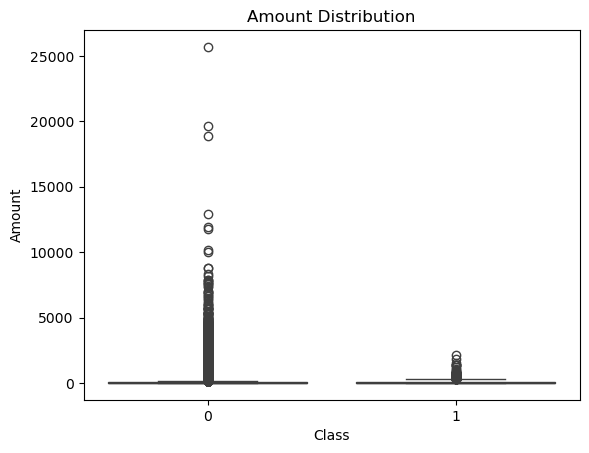

In [36]:
# 2) Amount Distribution
sns.boxplot(x=df["Class"], y=df["Amount"])
plt.title("Amount Distribution")
plt.show()

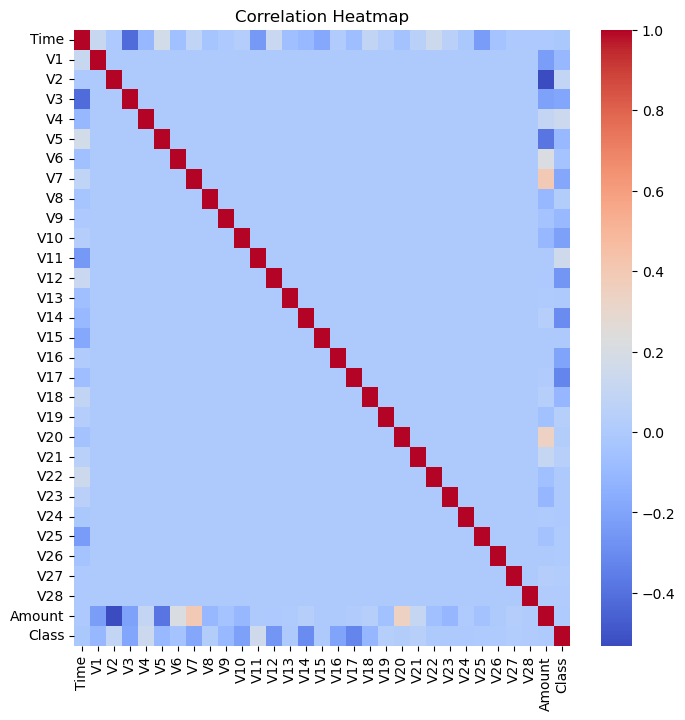

In [38]:
# 3) Correlation Heatmap
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [40]:
# Data Pre- Processing
X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
# Handling Imbalanced Data using SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("Before:", y.value_counts())
print("After SMOTE:", y_res.value_counts())

Before: Class
0    284315
1       492
Name: count, dtype: int64
After SMOTE: Class
0    284315
1    284315
Name: count, dtype: int64


In [45]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

In [47]:
# Modelling
xgb = XGBClassifier(max_depth=5, learning_rate=0.05, n_estimators=300, subsample=0.8, colsample_bytree=0.8,eval_metric='logloss')

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

In [48]:
# Model Evaluation

# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9979512160807555

Confusion Matrix:
 [[56690   173]
 [   60 56803]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726


ROC-AUC Score: 0.9999204407314842


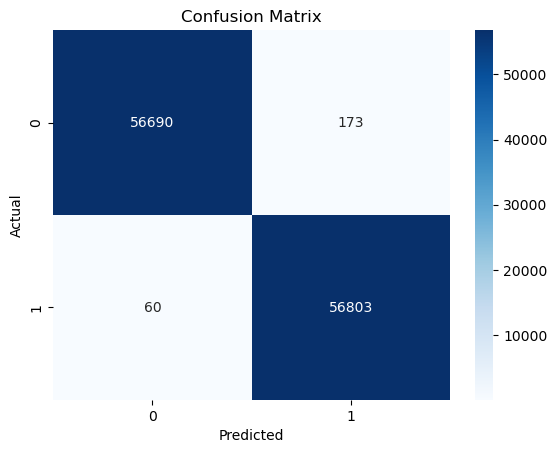

In [49]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 600x600 with 0 Axes>

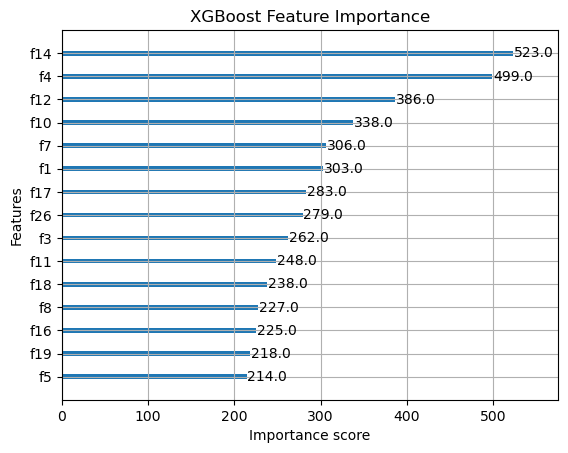

In [58]:
#Feature Importance
plt.figure(figsize=(6,6))
plot_importance(xgb, max_num_features=15)
plt.title("XGBoost Feature Importance")
plt.show()

In [60]:
importance = xgb.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({'Feature': importance.keys(),'Importance': importance.values()}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature   Importance
14     f14  5662.617676
10     f10  1186.450073
12     f12   912.287476
4       f4   688.728210
8       f8   462.022308
29     f29   272.037201
17     f17   271.565094
18     f18   268.352478
3       f3   246.483368
0       f0   222.307465
1       f1   216.836121
13     f13   205.649780
2       f2   176.066803
7       f7   172.701599
11     f11   170.370865
9       f9   170.344452
19     f19   165.629440
23     f23   159.970108
22     f22   149.977722
15     f15   144.957458
26     f26   138.534622
6       f6   117.622055
16     f16   117.075928
28     f28   116.721893
5       f5   116.122078
20     f20   114.796074
25     f25   111.205185
21     f21   110.513367
24     f24   101.426170
27     f27    92.562859


## Conclusion
The XGBoost model effectively detects fraudulent transactions in an imbalanced dataset.  
Although overall accuracy is high, metrics such as:
- Recall  
- Precision  
- F1-score are better indicators of real-world performance.

Feature importance insights can enhance fraud investigation and financial security.
The model can support banks & financial services to minimize monetary losses and improve safety.